# 06 — Cross-Era Transfer

Tests whether the Four Factors weights generalise across eras by prediction: the logistic-regression model is trained on one era and evaluated on the other, and the transferred performance is compared with native same-era performance. A small gap suggests the factor weights are stable across eras; a clear degradation suggests their relative importance shifted. Results are saved as a transfer matrix, a gap table, and a comparison figure.

## Setup and load

Import the libraries and load the NB02 feature matrix. The model is logistic regression on the
same 12 core Four Factors features as NB03/NB04 (`home`/`away`/`diff` for eFG, TOV%, ORB%,
FT-rate), scaled inside a pipeline. The two era blocks are early (2007-08 to 2011-12) and modern
(2020-21 to 2024-25), tagged by the `era` column.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "team_games_features.csv")

FACTORS = ["eFG", "TOV_pct", "ORB_pct", "FTrate"]
FEATURES = [f"{side}_{f}" for f in FACTORS for side in ["home", "away", "diff"]]


def logreg():
    return Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))])


early = df[df["era"] == "early"]
modern = df[df["era"] == "modern"]

## Predictions for the 2x2 matrix

For each test era, build two sets of predicted home-win probabilities, one per game:

- **Native (diagonal):** 5-fold cross-validation within the era (`shuffle=False`, so temporal
  order is kept), collecting the out-of-fold probability for every game. The scaler is fit on
  each training fold only.
- **Transfer (off-diagonal):** fit the scaler and model on the full *other* era, then transform
  and predict the full test era. The scaler is fit on the train era only, never on the test era.

`predictions` stores, for each test era, the true outcomes plus the native and transferred
probabilities aligned game-for-game.

In [2]:
cv = KFold(n_splits=5, shuffle=False)


def native_proba(era_df):
    # Out-of-fold probabilities within the era (scaler refit per fold).
    return cross_val_predict(logreg(), era_df[FEATURES], era_df["y"], cv=cv,
                             method="predict_proba")[:, 1]


def transfer_proba(train_df, test_df):
    # Fit on the full train era, predict the full test era.
    model = logreg().fit(train_df[FEATURES], train_df["y"])
    return model.predict_proba(test_df[FEATURES])[:, 1]


predictions = {
    "early": {
        "y": early["y"].to_numpy(),
        "native": native_proba(early),          # train early -> test early
        "transfer": transfer_proba(modern, early),  # train modern -> test early
    },
    "modern": {
        "y": modern["y"].to_numpy(),
        "native": native_proba(modern),         # train modern -> test modern
        "transfer": transfer_proba(early, modern),  # train early -> test modern
    },
}

## Metrics for each cell

Score every cell with accuracy, ROC-AUC, and log loss (log loss matters most here: it stresses
whether the transferred *probabilities*, not just the labels, hold up). The result is the 2x2
train-era x test-era matrix, saved to `06_transfer_matrix.csv`.

In [3]:
def score(y, p):
    pred = (p >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y, pred),
        "roc_auc": roc_auc_score(y, p),
        "log_loss": log_loss(y, p),
    }


cells = [
    ("early", "early", "native", predictions["early"]["y"], predictions["early"]["native"]),
    ("modern", "early", "transfer", predictions["early"]["y"], predictions["early"]["transfer"]),
    ("modern", "modern", "native", predictions["modern"]["y"], predictions["modern"]["native"]),
    ("early", "modern", "transfer", predictions["modern"]["y"], predictions["modern"]["transfer"]),
]

matrix_rows = []
for train_era, test_era, kind, y, p in cells:
    row = {"train_era": train_era, "test_era": test_era, "type": kind}
    row.update(score(y, p))
    matrix_rows.append(row)

transfer_matrix = pd.DataFrame(matrix_rows).round(4)
transfer_matrix.to_csv(PROCESSED_DIR / "06_transfer_matrix.csv", index=False)
transfer_matrix

,train_era,test_era,type,accuracy,roc_auc,log_loss
0,early,early,native,0.6324,0.6510,0.6392
1,modern,early,transfer,0.6337,0.6520,0.6404
2,modern,modern,native,0.6100,0.6405,0.6573
3,early,modern,transfer,0.6088,0.6419,0.6616


## Is the gap real?

The comparison of interest is within each test-era column: native vs transferred, with
**gap = native metric - transferred metric**. To judge whether a gap is real, bootstrap over the
test era's games (resample with replacement, 1,000 iterations). On each resample recompute both
native and transferred metrics and their difference; the 2.5th and 97.5th percentiles give a 95%
confidence interval. For accuracy and ROC-AUC a gap near 0 means stability (native does not beat
transfer); for log loss a gap near 0 likewise means the transferred probabilities hold up. The
gaps with CIs are saved to `06_transfer_gaps.csv`.

In [4]:
def bootstrap_gaps(y, p_native, p_transfer, n_iter=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y)
    metrics = ["accuracy", "roc_auc", "log_loss"]
    samples = {m: np.zeros(n_iter) for m in metrics}
    for i in range(n_iter):
        idx = rng.integers(0, n, n)
        nat = score(y[idx], p_native[idx])
        tra = score(y[idx], p_transfer[idx])
        for m in metrics:
            samples[m][i] = nat[m] - tra[m]
    return samples


gap_rows = []
for test_era in ["early", "modern"]:
    d = predictions[test_era]
    native_pt = score(d["y"], d["native"])
    transfer_pt = score(d["y"], d["transfer"])
    samples = bootstrap_gaps(d["y"], d["native"], d["transfer"])
    for m in ["accuracy", "roc_auc", "log_loss"]:
        lo, hi = np.percentile(samples[m], [2.5, 97.5])
        gap_rows.append({
            "test_era": test_era,
            "metric": m,
            "native": round(native_pt[m], 4),
            "transferred": round(transfer_pt[m], 4),
            "gap": round(native_pt[m] - transfer_pt[m], 4),
            "ci_low": round(lo, 4),
            "ci_high": round(hi, 4),
        })

transfer_gaps = pd.DataFrame(gap_rows)
transfer_gaps.to_csv(PROCESSED_DIR / "06_transfer_gaps.csv", index=False)
transfer_gaps

,test_era,metric,native,transferred,gap,ci_low,ci_high
0,early,accuracy,0.6324,0.6337,-0.0013,-0.0089,0.0060
1,early,roc_auc,0.6510,0.6520,-0.0010,-0.0040,0.0025
2,early,log_loss,0.6392,0.6404,-0.0012,-0.0034,0.0007
3,modern,accuracy,0.6100,0.6088,0.0012,-0.0080,0.0100
4,modern,roc_auc,0.6405,0.6419,-0.0014,-0.0044,0.0018
5,modern,log_loss,0.6573,0.6616,-0.0043,-0.0074,-0.0015


## Comparison figure

Native vs transferred ROC-AUC per test era, side by side, for the write-up and dashboard. Bars
at similar heights within each era are the visual signature of weight stability.

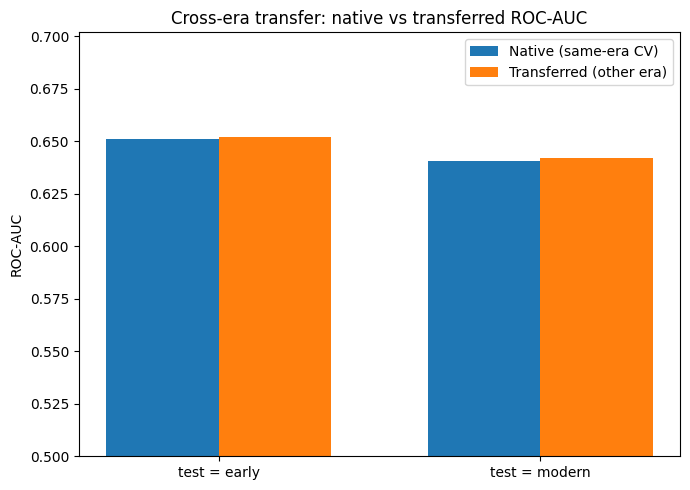

In [5]:
eras = ["early", "modern"]
native_auc = [score(predictions[e]["y"], predictions[e]["native"])["roc_auc"] for e in eras]
transfer_auc = [score(predictions[e]["y"], predictions[e]["transfer"])["roc_auc"] for e in eras]

x = np.arange(len(eras))
bar_w = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - bar_w / 2, native_auc, bar_w, label="Native (same-era CV)")
ax.bar(x + bar_w / 2, transfer_auc, bar_w, label="Transferred (other era)")

ax.set_xticks(x)
ax.set_xticklabels([f"test = {e}" for e in eras])
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.5, max(native_auc + transfer_auc) + 0.05)
ax.set_title("Cross-era transfer: native vs transferred ROC-AUC")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "06_transfer_comparison.png", dpi=150)
plt.show()

## Interpretation hook

Combine the transfer result with NB04's per-era standardised coefficients to place the finding
in one of three cases:

- coefficients similar **and** transfer holds -> clean stability.
- coefficients similar **but** transfer degrades -> the gap is likely raw-level distribution
  shift (e.g. modern eFG% sits higher), not a change in the weights.
- coefficients differ **and** transfer degrades -> a genuine importance shift.

"Coefficients similar" is read from NB04: all four factor CIs overlapping across eras. "Transfer
holds" is read here: the log-loss gap CI for both test eras comfortably spanning ~0. The printed
hook states which case the numbers support, in importance-stability language.

In [6]:
importance = pd.read_csv(PROCESSED_DIR / "04_importance_results.csv")
coefs_similar = (importance["ci_overlap"] == "yes").all()

ll_gaps = transfer_gaps[transfer_gaps["metric"] == "log_loss"]
transfer_holds = bool((ll_gaps["ci_low"] <= 0).all() and (ll_gaps["ci_high"] >= 0).all())

if coefs_similar and transfer_holds:
    case = ("clean stability: the Four Factors weights generalise across eras. The standardised "
            "coefficients overlap between eras and transferred log loss matches native within "
            "bootstrap noise, so two independent methods agree the relative importance is stable.")
elif coefs_similar and not transfer_holds:
    case = ("distribution shift, not a weight change: the per-era coefficients overlap, yet "
            "transferred probabilities degrade. This points to a raw-level shift in factor "
            "distributions across eras rather than a change in the factor weights; flagged "
            "explicitly so it is not read as an importance shift.")
else:
    case = ("genuine importance shift: the per-era coefficients differ and transferred "
            "performance degrades, so the relative importance of the Four Factors changed "
            "between eras.")

print("Cross-era transfer interpretation")
print("=" * 60)
print(f"NB04 coefficients similar across eras: {coefs_similar}")
print(f"Transferred log loss holds (gap CI spans 0): {transfer_holds}")
print()
print(case)

Cross-era transfer interpretation
NB04 coefficients similar across eras: True
Transferred log loss holds (gap CI spans 0): False

distribution shift, not a weight change: the per-era coefficients overlap, yet transferred probabilities degrade. This points to a raw-level shift in factor distributions across eras rather than a change in the factor weights; flagged explicitly so it is not read as an importance shift.
